<a href="https://colab.research.google.com/github/yasfmonteiro/Atividades-Estatistica-2026/blob/main/tarefa05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Integrantes
- Yasmin Almeida - 16992205
- Yasmin Agatha - 16905367
- Yasmin Monteiro - 17068161

Entre proteína e gordura, qual apresenta maior variabilidade? Como você
poderia comparar essa variabilidade considerando também os diferentes níveis
médios das duas variáveis?

In [ ]:
import pandas as pd

# Load the Excel file
df = pd.read_excel('/content/usda_data.xlsx')

# Display the first 5 rows and column information to understand the data structure
display(df.head())
df.info()

,ID,Alimento,Categoria,Proteína (g),Gordura total (g),Sódio (mg),fdc_id
0,1,"Rúcula, baby, crua",Vegetais e Produtos Vegetais,1.648750,0.3250,86.93,2710822
1,2,"Aspargos verdes, crus",Vegetais e Produtos Vegetais,1.437500,0.2163,2.46,2710823
2,3,"Vagem, enlatada, embalagem comum, escorrida",Vegetais e Produtos Vegetais,1.040000,0.3900,282.00,321611
3,4,"Vagem, crua",Vegetais e Produtos Vegetais,1.968750,0.2750,0.00,2346400
4,5,"Folhas de beterraba, cruas",Vegetais e Produtos Vegetais,1.609375,0.1438,280.50,2747653


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 100 non-null    int64  
 1   Alimento           100 non-null    object 
 2   Categoria          100 non-null    object 
 3   Proteína (g)       100 non-null    float64
 4   Gordura total (g)  100 non-null    float64
 5   Sódio (mg)         100 non-null    float64
 6   fdc_id             100 non-null    int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 5.6+ KB


In [ ]:
# Select the columns for Protein and Fat
protein = df['Proteína (g)']
fat = df['Gordura total (g)']

# Calculate mean and standard deviation for Protein
protein_mean = protein.mean()
protein_std = protein.std()

# Calculate mean and standard deviation for Fat
fat_mean = fat.mean()
fat_std = fat.std()

# Calculate the Coefficient of Variation (CV) for Protein and Fat
# CV = (Standard Deviation / Mean) * 100
protein_cv = (protein_std / protein_mean) * 100
fat_cv = (fat_std / fat_mean) * 100

# Display the results
print(f"--- Proteína (g) ---")
print(f"Média: {protein_mean:.2f}")
print(f"Desvio Padrão: {protein_std:.2f}")
print(f"Coeficiente de Variação (CV): {protein_cv:.2f}%")
print(f"\n--- Gordura total (g) ---")
print(f"Média: {fat_mean:.2f}")
print(f"Desvio Padrão: {fat_std:.2f}")
print(f"Coeficiente de Variação (CV): {fat_cv:.2f}%")

--- Proteína (g) ---
Média: 12.17
Desvio Padrão: 9.20
Coeficiente de Variação (CV): 75.60%

--- Gordura total (g) ---
Média: 6.88
Desvio Padrão: 9.63
Coeficiente de Variação (CV): 139.99%


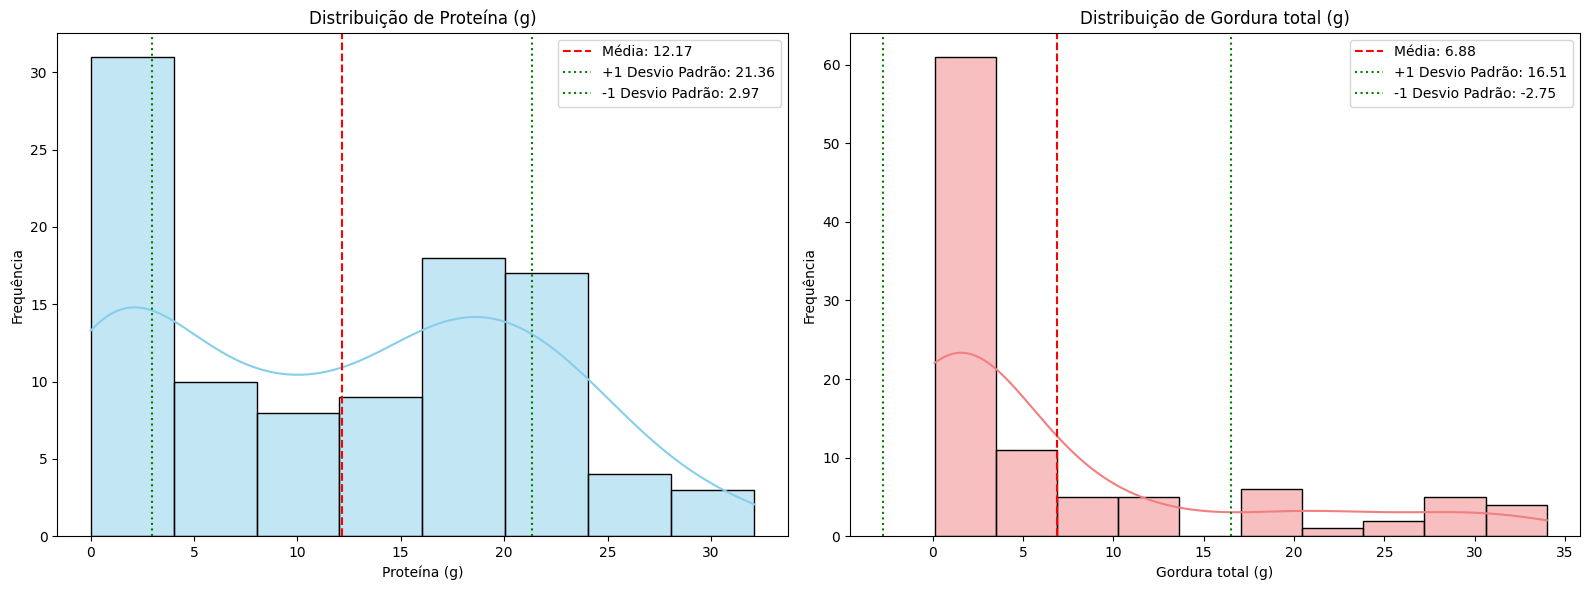

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots for the histograms
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for Protein (g)
sns.histplot(protein, kde=True, ax=axes[0], color='skyblue')
axes[0].axvline(protein_mean, color='red', linestyle='--', label=f'Média: {protein_mean:.2f}')
axes[0].axvline(protein_mean + protein_std, color='green', linestyle=':', label=f'+1 Desvio Padrão: {protein_mean + protein_std:.2f}')
axes[0].axvline(protein_mean - protein_std, color='green', linestyle=':', label=f'-1 Desvio Padrão: {protein_mean - protein_std:.2f}')
axes[0].set_title('Distribuição de Proteína (g)')
axes[0].set_xlabel('Proteína (g)')
axes[0].set_ylabel('Frequência')
axes[0].legend()

# Histogram for Fat (g)
sns.histplot(fat, kde=True, ax=axes[1], color='lightcoral')
axes[1].axvline(fat_mean, color='red', linestyle='--', label=f'Média: {fat_mean:.2f}')
axes[1].axvline(fat_mean + fat_std, color='green', linestyle=':', label=f'+1 Desvio Padrão: {fat_mean + fat_std:.2f}')
axes[1].axvline(fat_mean - fat_std, color='green', linestyle=':', label=f'-1 Desvio Padrão: {fat_mean - fat_std:.2f}')
axes[1].set_title('Distribuição de Gordura total (g)')
axes[1].set_xlabel('Gordura total (g)')
axes[1].set_ylabel('Frequência')
axes[1].legend()

plt.tight_layout()
plt.show()

Existe alguma relação entre o teor de proteína e o teor de gordura dos alimentos?
Como você poderia investigar visualmente essa possível relação?


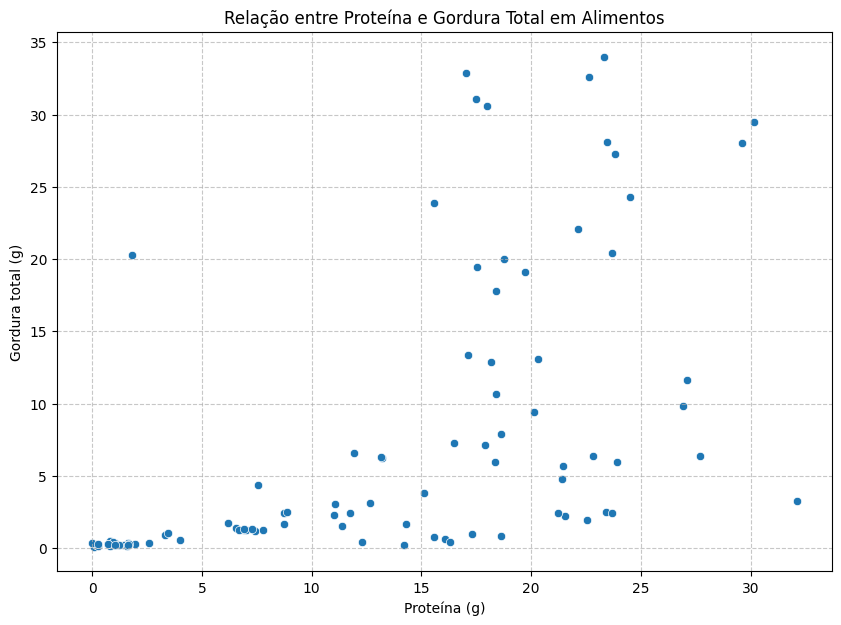

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x='Proteína (g)', y='Gordura total (g)', data=df)
plt.title('Relação entre Proteína e Gordura Total em Alimentos')
plt.xlabel('Proteína (g)')
plt.ylabel('Gordura total (g)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Calculate the covariance between protein and fat
covariance = df['Proteína (g)'].cov(df['Gordura total (g)'])

# Calculate the Pearson correlation coefficient between protein and fat
correlation = df['Proteína (g)'].corr(df['Gordura total (g)'])

print(f"Covariância entre Proteína e Gordura: {covariance:.2f}")
print(f"Correlação de Pearson entre Proteína e Gordura: {correlation:.2f}")

Covariância entre Proteína e Gordura: 52.67
Correlação de Pearson entre Proteína e Gordura: 0.59


In [ ]:
nutrient_columns = ['Proteína (g)', 'Gordura total (g)', 'Sódio (mg)']
descriptive_stats = df[nutrient_columns].agg(['mean', 'median', 'std'])
display(descriptive_stats)

,Proteína (g),Gordura total (g),Sódio (mg)
mean,12.166630,6.880802,273.091411
median,12.469720,2.066500,54.470000
std,9.198276,9.632325,665.830818


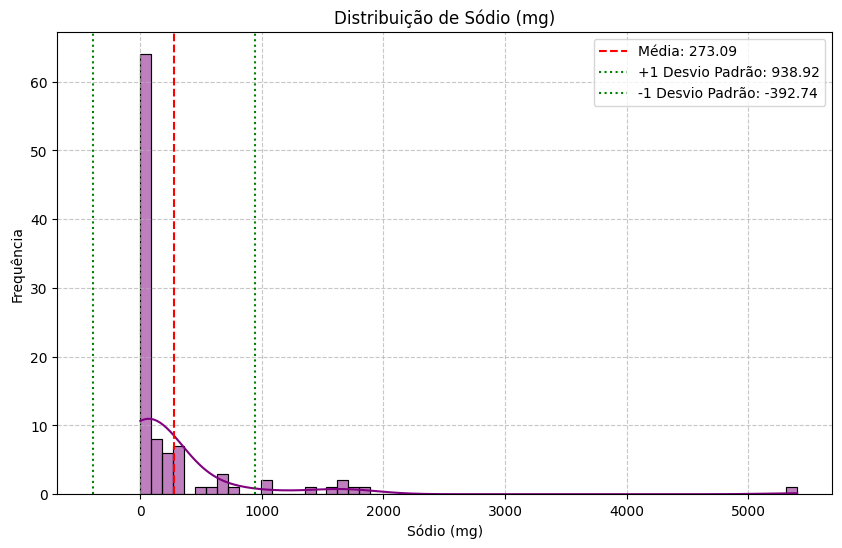

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sodium = df['Sódio (mg)']
sodium_mean = sodium.mean()
sodium_std = sodium.std()

plt.figure(figsize=(10, 6))
sns.histplot(sodium, kde=True, color='purple')
plt.axvline(sodium_mean, color='red', linestyle='--', label=f'Média: {sodium_mean:.2f}')
plt.axvline(sodium_mean + sodium_std, color='green', linestyle=':', label=f'+1 Desvio Padrão: {sodium_mean + sodium_std:.2f}')
plt.axvline(sodium_mean - sodium_std, color='green', linestyle=':', label=f'-1 Desvio Padrão: {sodium_mean - sodium_std:.2f}')
plt.title('Distribuição de Sódio (mg)')
plt.xlabel('Sódio (mg)')
plt.ylabel('Frequência')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()